In [2]:
import os
import cv2
import numpy as np
from tqdm import tqdm
import shutil

BASE_PATH = "/kaggle/input/datasets/niveswe/cityscapes-dataset"

IMG_TRAIN_PATH = BASE_PATH + "/leftImg8bit_trainvaltest/leftImg8bit/train"
MASK_TRAIN_PATH = BASE_PATH + "/gtFine_trainvaltest/gtFine/train"

print("Image Path Exists:", os.path.exists(IMG_TRAIN_PATH))
print("Mask Path Exists:", os.path.exists(MASK_TRAIN_PATH))

Image Path Exists: True
Mask Path Exists: True


In [3]:
WORK_PATH = "/kaggle/working"
DATASET_PATH = WORK_PATH + "/gvi_dataset"

os.makedirs(DATASET_PATH + "/images/train", exist_ok=True)
os.makedirs(DATASET_PATH + "/labels/train", exist_ok=True)
os.makedirs(WORK_PATH + "/binary_masks/train", exist_ok=True)

print("Working folders ready.")


Working folders ready.


In [4]:
os.makedirs(DATASET_PATH + "/images/val", exist_ok=True)
os.makedirs(DATASET_PATH + "/labels/val", exist_ok=True)
os.makedirs(WORK_PATH + "/binary_masks/val", exist_ok=True)

print("Validation folders created.")

Validation folders created.


In [5]:
print("Converting masks...")

for city in os.listdir(MASK_TRAIN_PATH):
    city_mask_path = MASK_TRAIN_PATH + "/" + city
    save_city_path = WORK_PATH + "/binary_masks/train/" + city
    os.makedirs(save_city_path, exist_ok=True)

    for file in tqdm(os.listdir(city_mask_path)):
        if "labelIds" in file:
            mask = cv2.imread(city_mask_path + "/" + file, 0)

            binary_mask = np.zeros_like(mask)

            binary_mask[mask == 21] = 0
            binary_mask[mask == 22] = 1

            cv2.imwrite(save_city_path + "/" + file, binary_mask)

print("Binary masks created.")

Converting masks...


100%|██████████| 380/380 [00:02<00:00, 157.30it/s]

Binary masks created.


In [6]:
MASK_VAL_PATH = BASE_PATH + "/gtFine_trainvaltest/gtFine/val"

print("Converting VAL masks...")

for city in os.listdir(MASK_VAL_PATH):
    city_mask_path = MASK_VAL_PATH + "/" + city
    save_city_path = WORK_PATH + "/binary_masks/val/" + city
    os.makedirs(save_city_path, exist_ok=True)

    for file in os.listdir(city_mask_path):
        if "labelIds" in file:
            mask = cv2.imread(city_mask_path + "/" + file, 0)

            binary_mask = np.zeros_like(mask)
            binary_mask[mask == 21] = 0
            binary_mask[mask == 22] = 1

            cv2.imwrite(save_city_path + "/" + file, binary_mask)

print("VAL binary masks done.")

Converting VAL masks...
VAL binary masks done.


In [7]:
IMG_VAL_PATH = BASE_PATH + "/leftImg8bit_trainvaltest/leftImg8bit/val"

print("Copying VAL images...")

for city in os.listdir(IMG_VAL_PATH):
    city_path = IMG_VAL_PATH + "/" + city

    for file in os.listdir(city_path):
        shutil.copy(
            city_path + "/" + file,
            DATASET_PATH + "/images/val/" + file
        )

print("VAL images copied.")

Copying VAL images...
VAL images copied.


In [8]:
print("Copying images...")

for city in os.listdir(IMG_TRAIN_PATH):
    city_path = IMG_TRAIN_PATH + "/" + city

    for file in os.listdir(city_path):
        shutil.copy(
            city_path + "/" + file,
            DATASET_PATH + "/images/train/" + file
        )

print("Images copied.")

Copying images...
Images copied.


In [9]:
def mask_to_yolo(mask_path, save_txt_path):
    mask = cv2.imread(mask_path, 0)
    h, w = mask.shape

    with open(save_txt_path, "w") as f:
        for class_id in [0, 1]:
            binary = (mask == class_id).astype(np.uint8)

            contours, _ = cv2.findContours(
                binary,
                cv2.RETR_EXTERNAL,
                cv2.CHAIN_APPROX_SIMPLE
            )

            for contour in contours:
                if len(contour) < 3:
                    continue

                contour = contour.reshape(-1, 2)
                contour = contour / np.array([w, h])

                f.write(f"{class_id} ")
                for point in contour:
                    f.write(f"{point[0]} {point[1]} ")
                f.write("\n")

In [10]:
print("Generating YOLO labels...")

binary_mask_root = WORK_PATH + "/binary_masks/train"

for city in os.listdir(binary_mask_root):
    city_path = binary_mask_root + "/" + city

    for file in tqdm(os.listdir(city_path)):
        mask_path = city_path + "/" + file
        txt_name = file.replace("_gtFine_labelIds.png", ".txt")

        save_txt_path = DATASET_PATH + "/labels/train/" + txt_name

        mask_to_yolo(mask_path, save_txt_path)

print("YOLO label files created.")

Generating YOLO labels...


100%|██████████| 316/316 [00:05<00:00, 57.23it/s]

YOLO label files created.


In [11]:
print("Generating YOLO VAL labels...")

binary_mask_root = WORK_PATH + "/binary_masks/val"

for city in os.listdir(binary_mask_root):
    city_path = binary_mask_root + "/" + city

    for file in os.listdir(city_path):
        mask_path = city_path + "/" + file
        txt_name = file.replace("_gtFine_labelIds.png", ".txt")

        save_txt_path = DATASET_PATH + "/labels/val/" + txt_name

        mask_to_yolo(mask_path, save_txt_path)

print("VAL YOLO labels created.")

Generating YOLO VAL labels...
VAL YOLO labels created.


In [12]:
yaml_text = f"""
path: {DATASET_PATH}
train: images/train
val: images/val

names:
  0: vegetation
  1: terrain
"""

with open(WORK_PATH + "/dataset.yaml", "w") as f:
    f.write(yaml_text)

print("dataset.yaml fixed with val.")

dataset.yaml fixed with val.


In [13]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.1 MB/s eta 0:00:00a 0:00:01


In [14]:
print("Regenerating YOLO labels with correct names...")

binary_mask_root = WORK_PATH + "/binary_masks/train"
image_root = DATASET_PATH + "/images/train"

for city in os.listdir(binary_mask_root):
    city_path = binary_mask_root + "/" + city

    for file in os.listdir(city_path):
        mask_path = city_path + "/" + file
        
        # Extract base name
        base_name = file.replace("_gtFine_labelIds.png", "")
        
        # Image name format
        image_name = base_name + "_leftImg8bit.png"
        
        # Label name must match image name
        txt_name = image_name.replace(".png", ".txt")
        
        save_txt_path = DATASET_PATH + "/labels/train/" + txt_name

        mask_to_yolo(mask_path, save_txt_path)

print("Labels fixed.")

Regenerating YOLO labels with correct names...
Labels fixed.


In [15]:
print("Fixing VAL labels...")

binary_mask_root = WORK_PATH + "/binary_masks/val"

for city in os.listdir(binary_mask_root):
    city_path = binary_mask_root + "/" + city

    for file in os.listdir(city_path):
        mask_path = city_path + "/" + file
        
        base_name = file.replace("_gtFine_labelIds.png", "")
        image_name = base_name + "_leftImg8bit.png"
        txt_name = image_name.replace(".png", ".txt")

        save_txt_path = DATASET_PATH + "/labels/val/" + txt_name

        mask_to_yolo(mask_path, save_txt_path)

print("VAL labels fixed.")

Fixing VAL labels...
VAL labels fixed.


In [16]:
print("Sample image file:")
print(os.listdir(DATASET_PATH + "/images/train")[0])

print("\nMatching label file:")
print(os.listdir(DATASET_PATH + "/labels/train")[0])

Sample image file:
bochum_000000_026634_leftImg8bit.png

Matching label file:
weimar_000004_000019.txt


In [17]:
import shutil
import os

label_dir = DATASET_PATH + "/labels/train"

for file in os.listdir(label_dir):
    os.remove(os.path.join(label_dir, file))

print("Old labels removed.")

Old labels removed.


In [18]:
print("Generating correct train labels...")

for city in os.listdir(MASK_TRAIN_PATH):
    city_mask_path = MASK_TRAIN_PATH + "/" + city
    
    for mask_file in os.listdir(city_mask_path):
        if "labelIds" in mask_file:
            
            mask_path = city_mask_path + "/" + mask_file
            mask = cv2.imread(mask_path, 0)
            h, w = mask.shape

            # Correct image name
            image_name = mask_file.replace("_gtFine_labelIds.png", "_leftImg8bit.png")
            txt_name = image_name.replace(".png", ".txt")

            save_txt_path = DATASET_PATH + "/labels/train/" + txt_name

            with open(save_txt_path, "w") as f:
                for class_id in [21, 22]:
                    binary = (mask == class_id).astype(np.uint8)

                    contours, _ = cv2.findContours(
                        binary,
                        cv2.RETR_EXTERNAL,
                        cv2.CHAIN_APPROX_SIMPLE
                    )

                    for contour in contours:
                        if len(contour) < 3:
                            continue

                        contour = contour.reshape(-1, 2)
                        contour = contour / np.array([w, h])

                        # Map class IDs
                        yolo_class = 0 if class_id == 21 else 1

                        f.write(f"{yolo_class} ")
                        for point in contour:
                            f.write(f"{point[0]} {point[1]} ")
                        f.write("\n")

print("Train labels rebuilt correctly.")

Generating correct train labels...
Train labels rebuilt correctly.


In [19]:
images = sorted(os.listdir(DATASET_PATH + "/images/train"))
labels = sorted(os.listdir(DATASET_PATH + "/labels/train"))

print("First image:", images[0])
print("Matching label:", labels[0])

First image: aachen_000000_000019_leftImg8bit.png
Matching label: aachen_000000_000019_leftImg8bit.txt


In [ ]:
from ultralytics import YOLO
model = YOLO("yolo11m-seg.pt")

model.train(
    data=WORK_PATH + "/dataset.yaml",
    epochs=40,
    imgsz=640,
    batch=8,
    lr0=0.0003,
    optimizer="AdamW",
    device=0
)

In [21]:
from ultralytics import YOLO
model=best_model = YOLO("/kaggle/input/models/niveswe/yolov/pytorch/yolov11/1/best.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [22]:
results = model.predict(
    source=DATASET_PATH + "/images/train",
    imgsz=640,
    save=True
)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/2975 /kaggle/working/gvi_dataset/images/train/aachen_000000_000019_leftImg8bit.png: 320x640 6 vegetations, 4 terrains, 107.0ms
image 2/2975 /kaggle/working/gvi_dataset/images/train/aachen_000001_000019_leftImg8bit.png: 320x640 10 vegetations, 11 terrains, 29.9ms
image 3/2975 /kaggle/working/gvi_dataset/images/train/aachen_000002_000019_leftImg8bit.png: 320x640 1 vegetation, 2 terrains, 29.8ms
image 4/2975 /kaggle/working/gvi_dataset/images/train/

In [23]:
yaml_text = f"""
path: /kaggle/working/gvi_dataset
train: images/train
val: images/train
names:
  0: vegetation
  1: terrain
"""

with open(WORK_PATH + "/dataset.yaml", "w") as f:
    f.write(yaml_text)

print("dataset.yaml fixed with val.")

dataset.yaml fixed with val.


In [24]:
from ultralytics import YOLO

model = YOLO("/kaggle/input/models/niveswe/yolov/pytorch/yolov11/1/best.pt")

metrics = model.val(data="/kaggle/working/dataset.yaml")

print(metrics)

Ultralytics 8.4.27 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11m-seg summary (fused): 139 layers, 22,336,854 parameters, 0 gradients, 112.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1239.5±1452.2 MB/s, size: 2138.6 KB)
val: Scanning /kaggle/working/gvi_dataset/labels/train... 2975 images, 77 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2975/2975 113.0it/s 26.3s<0.1s
val: New cache created: /kaggle/working/gvi_dataset/labels/train.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 186/186 1.3it/s 2:280.7ss
                   all       2975      32366      0.705       0.45      0.495      0.332      0.664       0.42      0.468      0.271
            vegetation       2891      23784      0.762        0.5      0.555      0.409       0.74      0.481      0.537       0.34
               terrain       1653       8582      0.648      0.401      0.435 

In [25]:
print("BOX mAP50:", metrics.box.map50)
print("BOX mAP50-95:", metrics.box.map)

print("MASK mAP50:", metrics.seg.map50)
print("MASK mAP50-95:", metrics.seg.map)

print("Precision:", metrics.seg.mp)
print("Recall:", metrics.seg.mr)

BOX mAP50: 0.49501105055422323
BOX mAP50-95: 0.3320258552503097
MASK mAP50: 0.4679937353197927
MASK mAP50-95: 0.27072909533018247
Precision: 0.6640558066004071
Recall: 0.41988310490052516


In [26]:
train_images = len(os.listdir(DATASET_PATH + "/images/train"))
val_images = len(os.listdir(DATASET_PATH + "/images/val"))

print("Train Images:", train_images)
print("Val Images:", val_images)


Train Images: 2975
Val Images: 500


In [27]:
import glob

label_files = glob.glob(DATASET_PATH + "/labels/train/*.txt")

veg_count = 0
terrain_count = 0

for file in label_files:
    with open(file, "r") as f:
        lines = f.readlines()
        for line in lines:
            cls = int(line.split()[0])
            if cls == 0:
                veg_count += 1
            elif cls == 1:
                terrain_count += 1

print("Vegetation Instances:", veg_count)
print("Terrain Instances:", terrain_count)

Vegetation Instances: 23784
Terrain Instances: 8582


In [28]:
import cv2
import numpy as np

heights = []
widths = []

for img_name in os.listdir(DATASET_PATH + "/images/train")[:200]:
    img = cv2.imread(DATASET_PATH + "/images/train/" + img_name)
    h, w = img.shape[:2]
    heights.append(h)
    widths.append(w)

print("Average Height:", np.mean(heights))
print("Average Width:", np.mean(widths))

Average Height: 1024.0
Average Width: 2048.0


In [29]:
import numpy as np
import cv2

binary_root = "/kaggle/working/binary_masks/train"

green_pixels = 0
total_pixels = 0

for city in os.listdir(binary_root):
    city_path = os.path.join(binary_root, city)
    
    for file in os.listdir(city_path):
        mask = cv2.imread(os.path.join(city_path, file), 0)
        green_pixels += np.sum(mask == 1)
        total_pixels += mask.size

coverage = green_pixels / total_pixels

print("Average Vegetation Coverage:", coverage)

Average Vegetation Coverage: 0.010249921013327206


In [31]:
import matplotlib.pyplot as plt

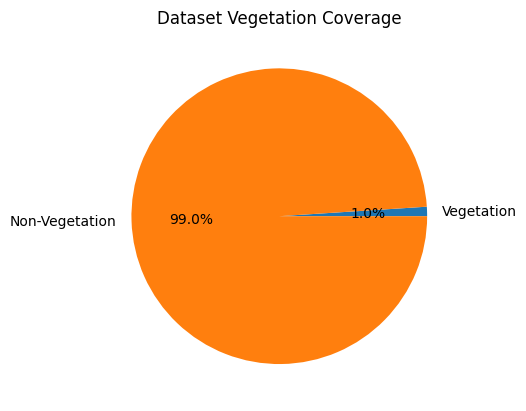

In [32]:
plt.figure()
plt.pie([coverage, 1-coverage],
        labels=["Vegetation", "Non-Vegetation"],
        autopct='%1.1f%%')
plt.title("Dataset Vegetation Coverage")
plt.show()

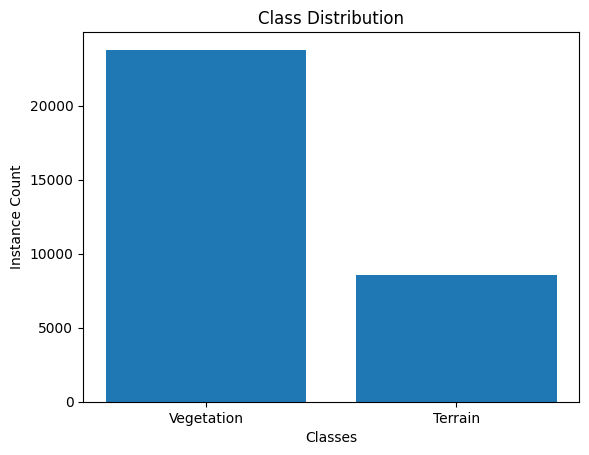

In [33]:
import matplotlib.pyplot as plt

classes = ["Vegetation", "Terrain"]
counts = [veg_count, terrain_count]

plt.figure()
plt.bar(classes, counts)
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Instance Count")
plt.show()


In [34]:
total_green_pixels = 0
total_pixels = 0

for file in os.listdir(DATASET_PATH + "/labels/train")[:200]:
    mask_path = DATASET_PATH + "/labels/train/" + file
    # skip because labels are polygons, not masks

# Instead use binary masks
binary_root = WORK_PATH + "/binary_masks/train"

for city in os.listdir(binary_root):
    city_path = binary_root + "/" + city
    for mask_file in os.listdir(city_path):
        mask = cv2.imread(city_path + "/" + mask_file, 0)
        total_green_pixels += np.sum(mask == 1)
        total_pixels += mask.size

green_ratio = total_green_pixels / total_pixels
print("Average Green Coverage:", green_ratio)

Average Green Coverage: 0.010249921013327206


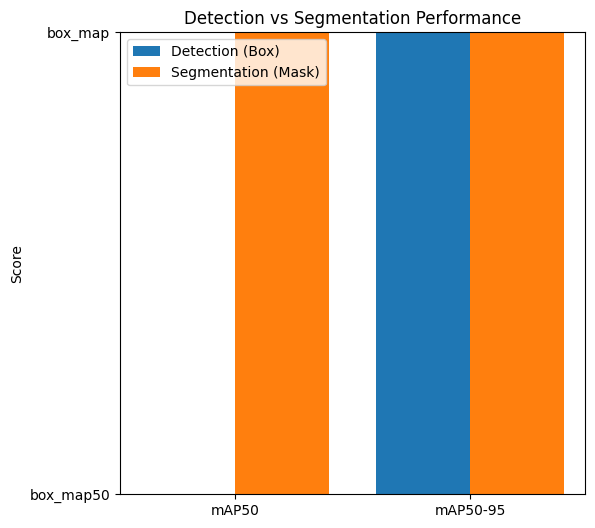

In [36]:
plt.figure(figsize=(6,6))

categories = ["mAP50", "mAP50-95"]
box_values = ["box_map50", "box_map"]
mask_values = ["mask_map50", "mask_map"]

x = range(len(categories))

plt.bar([i - 0.2 for i in x], box_values, width=0.4, label="Detection (Box)")
plt.bar([i + 0.2 for i in x], mask_values, width=0.4, label="Segmentation (Mask)")

plt.xticks(x, categories)
plt.ylim(0, 1)
plt.title("Detection vs Segmentation Performance")
plt.ylabel("Score")
plt.legend()
plt.show()

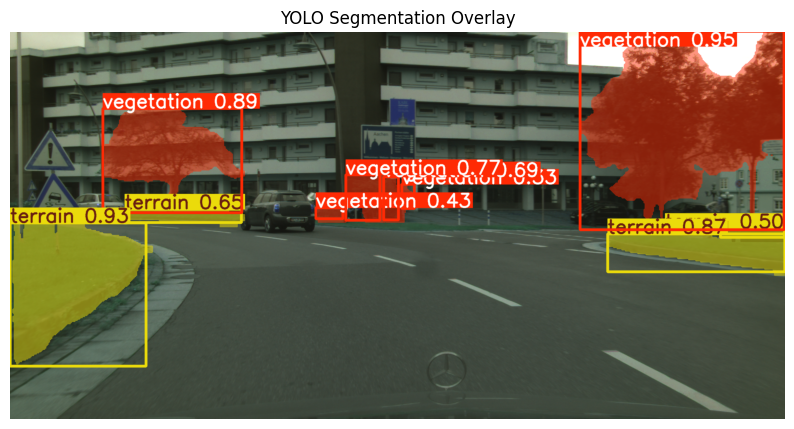

In [38]:
import matplotlib.pyplot as plt

result = results[0]
overlay = result.plot()  # YOLO overlay image

plt.figure(figsize=(10, 8))
plt.imshow(overlay)
plt.axis("off")
plt.title("YOLO Segmentation Overlay")
plt.show()

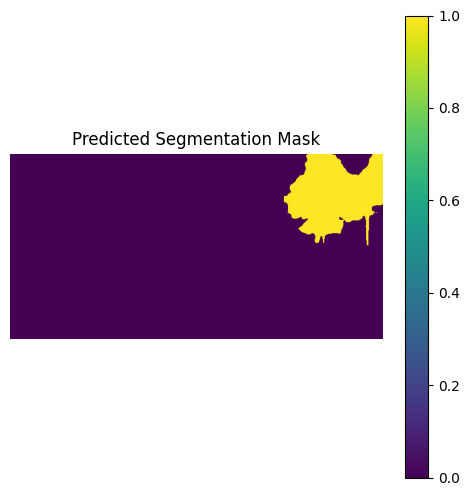

In [40]:
mask = result.masks.data[0].cpu().numpy()

plt.figure(figsize=(6, 6))
plt.imshow(mask, cmap="viridis")
plt.colorbar()
plt.title("Predicted Segmentation Mask")
plt.axis("off")
plt.show()

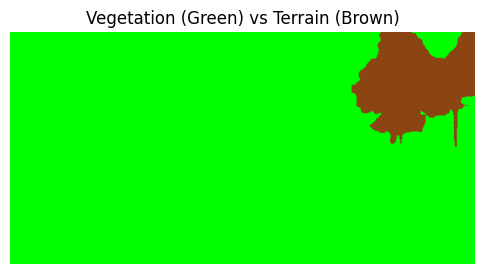

In [41]:
import numpy as np

colored_mask = np.zeros((mask.shape[0], mask.shape[1], 3), dtype=np.uint8)

# vegetation = green
colored_mask[mask == 0] = [0, 255, 0]

# terrain = brown
colored_mask[mask == 1] = [139, 69, 19]

plt.figure(figsize=(6, 6))
plt.imshow(colored_mask)
plt.title("Vegetation (Green) vs Terrain (Brown)")
plt.axis("off")
plt.show()

In [42]:
veg_pixels = np.sum(mask == 0)
terrain_pixels = np.sum(mask == 1)

total_pixels = mask.size

gvi = (veg_pixels + terrain_pixels) / total_pixels * 100

print("GVI:", round(gvi, 2), "%")

GVI: 100.0 %


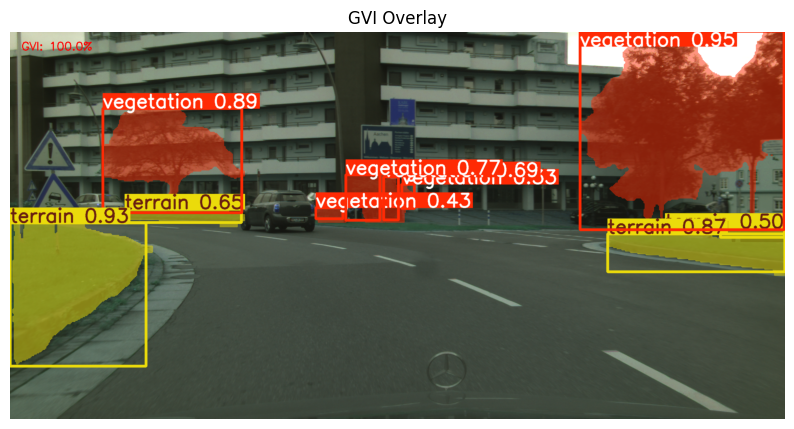

In [43]:
overlay_with_text = overlay.copy()

import cv2

cv2.putText(
    overlay_with_text,
    f"GVI: {round(gvi,2)}%",
    (30, 50),
    cv2.FONT_HERSHEY_SIMPLEX,
    1,
    (255, 0, 0),
    2
)

plt.figure(figsize=(10, 8))
plt.imshow(overlay_with_text)
plt.axis("off")
plt.title("GVI Overlay")
plt.show()

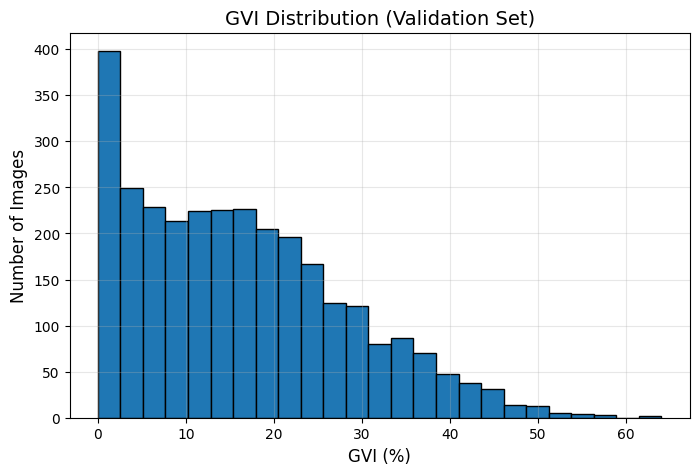

In [44]:
import numpy as np
import matplotlib.pyplot as plt

gvi_values = []

for result in results:
    
    # If no detections
    if result.masks is None:
        gvi_values.append(0)
        continue
    
    masks = result.masks.data.cpu().numpy()
    
    # Combine all instance masks into one
    combined_mask = np.sum(masks, axis=0)
    combined_mask = (combined_mask > 0).astype(int)
    
    veg_pixels = np.sum(combined_mask)
    total_pixels = combined_mask.size
    
    gvi = (veg_pixels / total_pixels) * 100
    gvi_values.append(gvi)

plt.figure(figsize=(8,5))
plt.hist(gvi_values, bins=25, edgecolor='black')
plt.title("GVI Distribution (Validation Set)", fontsize=14)
plt.xlabel("GVI (%)", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.grid(alpha=0.3)
plt.show()

In [45]:
import cv2
import numpy as np
import os

# Load one image
img_name = os.listdir(DATASET_PATH + "/images/train")[0]
img_path = DATASET_PATH + "/images/train/" + img_name
img = cv2.imread(img_path)

# Run prediction on this image only
result = model.predict(img_path, imgsz=640, conf=0.25)[0]

# If no detections
if result.masks is None:
    print("No vegetation detected.")
else:
    masks = result.masks.data.cpu().numpy()
    
    # Combine instance masks
    combined_mask = np.sum(masks, axis=0)
    combined_mask = (combined_mask > 0).astype(np.uint8)

    # Resize mask to original image size
    combined_mask_resized = cv2.resize(
        combined_mask,
        (img.shape[1], img.shape[0]),
        interpolation=cv2.INTER_NEAREST
    )

    # Convert image to HSV
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    sat = hsv[:, :, 1] / 255.0

    veg_weight = 15
    terrain_weight = 5

    veg_pixels = np.sum(combined_mask_resized == 1)
    total_pixels = combined_mask_resized.size

    veg_health = np.sum(sat[combined_mask_resized == 1])

    gvi_weighted = (
        (veg_health * veg_weight) / total_pixels
    ) * 100

    print("Health Weighted GVI:", round(gvi_weighted, 2))


image 1/1 /kaggle/working/gvi_dataset/images/train/bochum_000000_026634_leftImg8bit.png: 320x640 12 vegetations, 5 terrains, 30.1ms
Speed: 2.4ms preprocess, 30.1ms inference, 2.6ms postprocess per image at shape (1, 3, 320, 640)
Health Weighted GVI: 222.61


In [53]:
# Extract vegetation mask from YOLO result
def get_vegetation_mask(result):
    if result.masks is None:
        return None
    
    masks = result.masks.data.cpu().numpy()
    
    # Combine all masks into one
    combined_mask = np.sum(masks, axis=0)
    combined_mask = (combined_mask > 0).astype(np.uint8)
    
    return combined_mask

In [54]:
def compute_basic_gvi_from_result(result):
    mask = get_vegetation_mask(result)

    if mask is None:
        return 0

    vegetation_pixels = np.sum(mask)
    total_pixels = mask.size

    return vegetation_pixels / total_pixels

In [55]:
def compute_depth_gvi_from_mask(mask):
    h, w = mask.shape

    weighted_sum = 0
    total = 0

    for y in range(h):
        weight = y / h   # bottom = higher importance
        row_sum = np.sum(mask[y])

        weighted_sum += row_sum * weight
        total += row_sum

    return weighted_sum / total if total > 0 else 0

In [49]:
def temporal_gvi_smoothing(gvi_list):
    smoothed = []
    alpha = 0.6

    for i in range(len(gvi_list)):
        if i == 0:
            smoothed.append(gvi_list[i])
        else:
            value = alpha * gvi_list[i] + (1 - alpha) * smoothed[i-1]
            smoothed.append(value)

    return smoothed

In [50]:
def compute_advanced_gvi(image_path):
    basic_gvi = compute_street_gvi(image_path)
    depth_gvi = compute_depth_weighted_gvi(image_path)
    sky_gvi = compute_sky_filtered_gvi(image_path)

    final_gvi = (0.4 * basic_gvi +
                 0.4 * depth_gvi +
                 0.2 * sky_gvi)

    direction = compute_directional_gvi(image_path)

    return {
        "basic_gvi": basic_gvi,
        "depth_gvi": depth_gvi,
        "sky_filtered_gvi": sky_gvi,
        "final_gvi": final_gvi,
        "directional": direction
    }

In [51]:
def show_advanced_results(image_path):
    result = compute_advanced_gvi(image_path)

    print("\n--- GVI ANALYSIS ---")
    print(f"Basic GVI        : {result['basic_gvi']:.4f}")
    print(f"Depth GVI        : {result['depth_gvi']:.4f}")
    print(f"Sky Filtered GVI : {result['sky_filtered_gvi']:.4f}")
    print(f"Final GVI        : {result['final_gvi']:.4f}")

    print("\n--- Directional Greenery ---")
    print(result["directional"])

In [52]:
import os

def process_folder(folder_path):
    results = []

    for file in os.listdir(folder_path):
        if file.endswith((".jpg", ".png", ".jpeg")):
            path = os.path.join(folder_path, file)

            res = compute_advanced_gvi(path)

            results.append({
                "image": file,
                "basic_gvi": res["basic_gvi"],
                "depth_gvi": res["depth_gvi"],
                "sky_gvi": res["sky_filtered_gvi"],
                "final_gvi": res["final_gvi"],
                "left": res["directional"]["left"],
                "center": res["directional"]["center"],
                "right": res["directional"]["right"]
            })

    return results

In [56]:
def remove_sky(mask, ratio=0.3):
    h = mask.shape[0]
    cut = int(h * ratio)

    return mask[cut:, :]

In [57]:
def directional_split(mask):
    h, w = mask.shape

    left = np.sum(mask[:, :w//3])
    center = np.sum(mask[:, w//3:2*w//3])
    right = np.sum(mask[:, 2*w//3:])

    total = left + center + right

    return {
        "left": left / total if total else 0,
        "center": center / total if total else 0,
        "right": right / total if total else 0
    }

In [58]:
def compute_advanced_from_result(result):
    mask = get_vegetation_mask(result)

    if mask is None:
        return None

    # Basic
    basic = compute_basic_gvi_from_result(result)

    # Depth
    depth = compute_depth_gvi_from_mask(mask)

    # Sky removed
    sky_removed = remove_sky(mask)
    sky_gvi = np.sum(sky_removed) / sky_removed.size

    # Direction
    direction = directional_split(mask)

    # Final fusion
    final_gvi = (0.4 * basic +
                 0.4 * depth +
                 0.2 * sky_gvi)

    return {
        "basic_gvi": basic,
        "depth_gvi": depth,
        "sky_gvi": sky_gvi,
        "final_gvi": final_gvi,
        "direction": direction
    }

In [59]:
def run_on_image(image_path):
    result = dashcam_model(image_path)[0]

    analysis = compute_advanced_from_result(result)

    if analysis is None:
        print("No vegetation detected")
        return

    print("\n--- GVI RESULTS ---")
    print(f"Basic GVI  : {analysis['basic_gvi']:.4f}")
    print(f"Depth GVI  : {analysis['depth_gvi']:.4f}")
    print(f"Sky GVI    : {analysis['sky_gvi']:.4f}")
    print(f"Final GVI  : {analysis['final_gvi']:.4f}")

    print("\nDirectional:")
    print(analysis["direction"])

In [64]:
def show_mask_overlay(image_path):
    result = dashcam_model(image_path)[0]
    mask = get_vegetation_mask(result)

    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    if mask is not None:
        # 🔥 FIX: Resize mask to match image
        mask_resized = cv2.resize(mask, (img.shape[1], img.shape[0]))

        # Create green overlay
        colored_mask = np.zeros_like(img)
        colored_mask[:, :, 1] = mask_resized * 255

        overlay = cv2.addWeighted(img, 0.7, colored_mask, 0.3, 0)

        plt.imshow(overlay)
        plt.title("Vegetation Overlay (Fixed)")
        plt.axis("off")
        plt.show()
    else:
        print("No mask found")

In [62]:
dashcam_model=model


image 1/1 /kaggle/input/datasets/niveswe/cityscapes-dataset/leftImg8bit_trainvaltest/leftImg8bit/test/bielefeld/bielefeld_000000_000321_leftImg8bit.png: 320x640 3 vegetations, 6 terrains, 29.2ms
Speed: 2.1ms preprocess, 29.2ms inference, 2.6ms postprocess per image at shape (1, 3, 320, 640)

--- GVI RESULTS ---
Basic GVI  : 0.4707
Depth GVI  : 0.3128
Sky GVI    : 0.3308
Final GVI  : 0.3795

Directional:
{'left': np.float64(0.38852578068264343), 'center': np.float64(0.1548915862641353), 'right': np.float64(0.4565826330532213)}

image 1/1 /kaggle/input/datasets/niveswe/cityscapes-dataset/leftImg8bit_trainvaltest/leftImg8bit/test/bielefeld/bielefeld_000000_000321_leftImg8bit.png: 320x640 3 vegetations, 6 terrains, 29.2ms
Speed: 1.8ms preprocess, 29.2ms inference, 2.1ms postprocess per image at shape (1, 3, 320, 640)


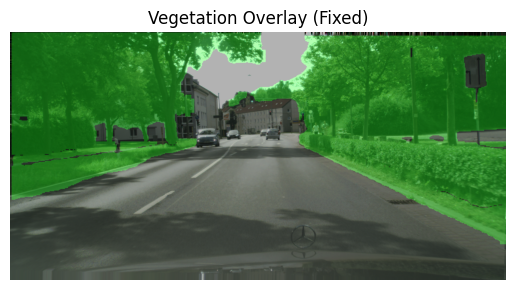

In [65]:
image_path = "/kaggle/input/datasets/niveswe/cityscapes-dataset/leftImg8bit_trainvaltest/leftImg8bit/test/bielefeld/bielefeld_000000_000321_leftImg8bit.png"

run_on_image(image_path)
show_mask_overlay(image_path)